# Preprocessing, Methodology & Aura Score Model

**Fixes applied in this version:**

| # | Problem | Fix |
|---|---|---|
| 1 | Circular target — built from the same features given to RF | Replaced with empirical xT Markov model fit from real match outcomes |
| 2 | Pre-stated result ("midfielders ~30% higher") before analysis | Removed — result must come from the data |
| 3 | No leakage check | Added correlation check before every model fit |
| 4 | APLB/DSI/press_resilience in BOTH target AND feature_cols | Removed composite terms from feature_cols entirely |
| 5 | "Held-out test" was 20% of training matches, not Euro 2024 | Clearly labelled — Euro 2024 loaded and tested properly |
| 6 | RF max_depth=8/10, min_samples_leaf=8 — too aggressive | Fixed to max_depth=6, min_samples_leaf=20 |
| 7 | type column stored as dict-string from API | Parsed with extract_name() before any comparison |

In [1]:
# %pip install -q --user statsbombpy seaborn pandas numpy matplotlib scipy scikit-learn shap

import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler
from statsbombpy import sb

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial']
plt.rcParams['axes.edgecolor'] = '#cccccc'

# Robust root directory resolution
cwd = os.getcwd()
if os.path.basename(cwd) == 'Notebooks':
    PROJECT_ROOT = os.path.abspath(os.path.join(cwd, '..'))
else:
    PROJECT_ROOT = os.path.abspath(cwd)

DATA_DIR = os.path.join(PROJECT_ROOT, 'data')
FIG_DIR  = os.path.join(PROJECT_ROOT, 'figures')
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)
print(f"✓ Project root: {PROJECT_ROOT}")

# ─── Helper: safely extract 'name' from dict-or-string StatsBomb fields ────
def extract_name(val):
    if isinstance(val, dict):
        return val.get('name', '')
    if isinstance(val, str):
        import re
        m = re.search(r"'name':\s*'([^']+)'", val)
        if m:
            return m.group(1)
    return str(val) if pd.notna(val) else ''

print("✓ extract_name() helper defined — handles both API dict and CSV string formats")


✓ Project root: /Users/prova/Documents/cse490d-project
✓ extract_name() helper defined — handles both API dict and CSV string formats


## Step 2: Load or Fetch Training Data (Fully Reproducible from StatsBomb API)

In [2]:
# ─── 360 Feature Extractor & Live API Ingestion ──────────────────────────────
def _calc_dist_angle(x, y, gx=120, gy=40):
    dx, dy = gx - x, gy - y
    return math.sqrt(dx**2 + dy**2), (math.atan2(abs(dy), dx) if dx > 0 else 0)

def process_360_frame_features(frame_df, event_x, event_y, end_x=np.nan, end_y=np.nan, is_complete=True):
    """Full 360 feature extractor — matches Notebook 1 exactly."""
    empty = {
        'has_360': False, 'teammates_visible': np.nan, 'opponents_visible': np.nan,
        'total_visible': np.nan, 'closest_opp_dist': np.nan, 'closest_teammate_dist': np.nan,
        'opponents_within_3m': np.nan, 'opponents_within_5m': np.nan,
        'defenders_in_goal_cone': np.nan, 'forward_passing_options': np.nan,
        'opponents_eliminated': np.nan, 'line_breaking_pass': False,
        'pressing_intensity': np.nan, 'defensive_cover': np.nan,
        'central_corridor': np.nan, 'spatial_superiority': np.nan,
        'short_combo_options': np.nan
    }
    if frame_df is None or frame_df.empty:
        return empty

    teammates_rows = frame_df[frame_df['teammate'] == True]
    opponents_rows = frame_df[frame_df['teammate'] == False]
    
    n_team = len(teammates_rows)
    n_opp  = len(opponents_rows)
    
    opp_locs = [f['location'] for _, f in opponents_rows.iterrows() if isinstance(f['location'], (list, tuple)) and len(f['location']) >= 2]
    team_locs = [f['location'] for _, f in teammates_rows.iterrows() if isinstance(f['location'], (list, tuple)) and len(f['location']) >= 2]
    
    opp_dists = [math.sqrt((ox - event_x)**2 + (oy - event_y)**2) for ox, oy in opp_locs]
    team_dists = [math.sqrt((tx - event_x)**2 + (ty - event_y)**2) for tx, ty in team_locs]
    
    closest_opp = min(opp_dists) if opp_dists else np.nan
    closest_tm  = min(team_dists) if team_dists else np.nan
    opp_3m      = sum(1 for d in opp_dists if d <= 3.0)
    opp_5m      = sum(1 for d in opp_dists if d <= 5.0)
    
    cone_count = 0
    for ox, oy in opp_locs:
        if ox > event_x and abs(oy - 40.0) <= ((ox - event_x) / max(1.0, 120.0 - event_x)) * 30.0 + 4.0:
            cone_count += 1
            
    fwd_tm = sum(1 for tx, ty in team_locs if tx > event_x + 2.0)
    
    elim = 0
    line_break = False
    if not np.isnan(end_x) and is_complete and end_x > event_x:
        for ox, oy in opp_locs:
            if event_x < ox <= end_x:
                elim += 1
        line_break = elim >= 2
        
    press_int = (1.0 / (closest_opp + 0.5)) if not np.isnan(closest_opp) else 0.0
    def_cov = sum(1 for ox, oy in opp_locs if ox > event_x and abs(oy - event_y) <= 8.0)
    cent_corr = sum(1 for ox, oy in opp_locs if 20.0 <= oy <= 60.0 and ox > event_x)
    spat_sup = float(sum(1 for d in team_dists if d <= 7.0) - sum(1 for d in opp_dists if d <= 7.0))
    short_combo = sum(1 for d in team_dists if d <= 10.0)
    
    return {
        'has_360': True,
        'teammates_visible': n_team,
        'opponents_visible': n_opp,
        'total_visible': n_team + n_opp,
        'closest_opp_dist': round(closest_opp, 3) if not np.isnan(closest_opp) else np.nan,
        'closest_teammate_dist': round(closest_tm, 3) if not np.isnan(closest_tm) else np.nan,
        'opponents_within_3m': opp_3m,
        'opponents_within_5m': opp_5m,
        'defenders_in_goal_cone': cone_count,
        'forward_passing_options': fwd_tm,
        'opponents_eliminated': elim,
        'line_breaking_pass': line_break,
        'pressing_intensity': round(press_int, 4),
        'defensive_cover': def_cov,
        'central_corridor': cent_corr,
        'spatial_superiority': spat_sup,
        'short_combo_options': short_combo
    }

csv_path = os.path.join(DATA_DIR, 'sample_processed_events_with_360.csv')
if os.path.exists(csv_path):
    print(f"Loading training dataset from {csv_path}...")
    df = pd.read_csv(csv_path, low_memory=False)
else:
    print("Fetching World Cup 2022 & Euro 2020 training matches live from StatsBomb Open API...")
    matches_wc = sb.matches(competition_id=43, season_id=106)
    matches_euro = sb.matches(competition_id=55, season_id=43)
    sample_wc = matches_wc.sort_values(by='match_date', ascending=False).head(8)['match_id'].tolist()
    sample_euro = matches_euro.sort_values(by='match_date', ascending=False).head(7)['match_id'].tolist()
    sample_match_ids = sample_wc + sample_euro

    all_events = []
    for i, mid in enumerate(sample_match_ids, 1):
        print(f"  [{i}/{len(sample_match_ids)}] Downloading match {mid}...")
        evs = sb.events(match_id=mid)
        try:
            frs = sb.frames(match_id=mid, fmt='dataframe')
        except Exception:
            frs = pd.DataFrame()
        frames_by_id = {}
        if not frs.empty:
            for ev_id, grp in frs.groupby('id'):
                frames_by_id[ev_id] = grp
        for _, ev in evs.iterrows():
            loc = ev.get('location')
            loc_x = loc[0] if isinstance(loc, (list, tuple, np.ndarray)) and len(loc) >= 2 else np.nan
            loc_y = loc[1] if isinstance(loc, (list, tuple, np.ndarray)) and len(loc) >= 2 else np.nan
            pe = ev.get('pass_end_location')
            pe_x = pe[0] if isinstance(pe, (list, tuple)) and len(pe) >= 2 else np.nan
            pe_y = pe[1] if isinstance(pe, (list, tuple)) and len(pe) >= 2 else np.nan
            ce = ev.get('carry_end_location')
            ce_x = ce[0] if isinstance(ce, (list, tuple)) and len(ce) >= 2 else np.nan
            ce_y = ce[1] if isinstance(ce, (list, tuple)) and len(ce) >= 2 else np.nan
            end_x = pe_x if not np.isnan(pe_x) else ce_x
            end_y = pe_y if not np.isnan(pe_y) else ce_y
            is_comp = pd.isna(ev.get('pass_outcome'))
            dg, ag = _calc_dist_angle(loc_x, loc_y) if not np.isnan(loc_x) else (np.nan, np.nan)
            f_df = frames_by_id.get(ev.get('id'), None)
            f_feats = process_360_frame_features(f_df, loc_x, loc_y, end_x, end_y, is_comp) if not np.isnan(loc_x) else process_360_frame_features(None, 0, 0)
            all_events.append({
                'event_id': ev.get('id'), 'match_id': mid, 'period': ev.get('period'),
                'minute': ev.get('minute'), 'second': ev.get('second'),
                'type': ev.get('type'), 'possession': ev.get('possession'),
                'possession_team': ev.get('possession_team'), 'play_pattern': ev.get('play_pattern'),
                'team': ev.get('team'), 'player': ev.get('player'), 'position': ev.get('position'),
                'duration': ev.get('duration', 0.0), 'location_x': loc_x, 'location_y': loc_y,
                'dist_to_goal': dg, 'angle_to_goal': ag, 'under_pressure': ev.get('under_pressure') == True,
                'pass_length': ev.get('pass_length', np.nan), 'pass_angle': ev.get('pass_angle', np.nan),
                'pass_end_location_x': pe_x, 'pass_end_location_y': pe_y,
                'carry_end_location_x': ce_x, 'carry_end_location_y': ce_y,
                'pass_outcome': ev.get('pass_outcome', np.nan),
                'shot_statsbomb_xg': ev.get('shot_statsbomb_xg', np.nan),
                'shot_outcome': ev.get('shot_outcome', np.nan),
                **f_feats
            })
    df = pd.DataFrame(all_events)
    try:
        df.to_csv(csv_path, index=False)
    except Exception:
        pass

# Fix the type column — handles dict-string or plain string formats
df['type_name']         = df['type'].apply(extract_name)
df['play_pattern_name'] = df['play_pattern'].apply(extract_name)
df['pass_outcome_name'] = df['pass_outcome'].apply(extract_name)

df_360 = df[df['has_360'] == True].copy()

print(f"\n✓ Total events    : {len(df):,}")
print(f"✓ Events with 360 : {len(df_360):,}")
print(f"✓ Unique matches  : {df['match_id'].nunique()}")
print(f"✓ Unique players  : {df['player'].apply(extract_name).nunique()}")
print(f"\nTop event types:")
print(df['type_name'].value_counts().head(8))
print(f"\nopponents_eliminated — non-null: {df_360['opponents_eliminated'].notna().sum():,}")
print(f"opponents_eliminated — mean: {df_360['opponents_eliminated'].mean():.3f}, max: {df_360['opponents_eliminated'].max()}")


Loading training dataset from /Users/prova/Documents/cse490d-project/data/sample_processed_events_with_360.csv...



✓ Total events    : 62,194
✓ Events with 360 : 53,207
✓ Unique matches  : 15
✓ Unique players  : 263

Top event types:
type_name
Pass             17821
Ball Receipt*    16900
Carry            14590
Pressure          4657
Ball Recovery     1382
Duel              1063
Clearance          626
Block              534
Name: count, dtype: int64

opponents_eliminated — non-null: 53,207
opponents_eliminated — mean: 0.331, max: 11.0


## Step 2.5: Empirical xT Grid (Markov Model — fit from real match outcomes)

**Why this instead of the previous formula?**

The previous `action_value` was built from `APLB`, `DSI`, `press_resilience` — all derived from the same 360 features passed to the Random Forest. The RF then predicted a target it was already partially explaining. SHAP reflected our own weights back at us, not anything real.

The empirical xT approach (Karun Singh, 2019) fits a Markov chain on actual match transitions:
- `xT(zone) = P(shoot | zone) × E[xG | zone] + P(move | zone) × Σ T(zone → zone') × xT(zone')`
- **Fit on the full event stream** (not just 360-tagged events, not the features)
- **No hand-picked weights** — every number comes from actual football outcomes
- **Zero overlap** with the 360 features used as X — the xT grid only uses location and outcome flags

✓ xT grid fit from 61,622 events (no 360 features used).
  xT range: 0.00000 → 0.19272
  Penalty spot zone xT ≈ 0.1927  (should be high ~0.3-0.7)
  Own half midfield xT ≈ 0.0000 (should be low ~0.01-0.05)


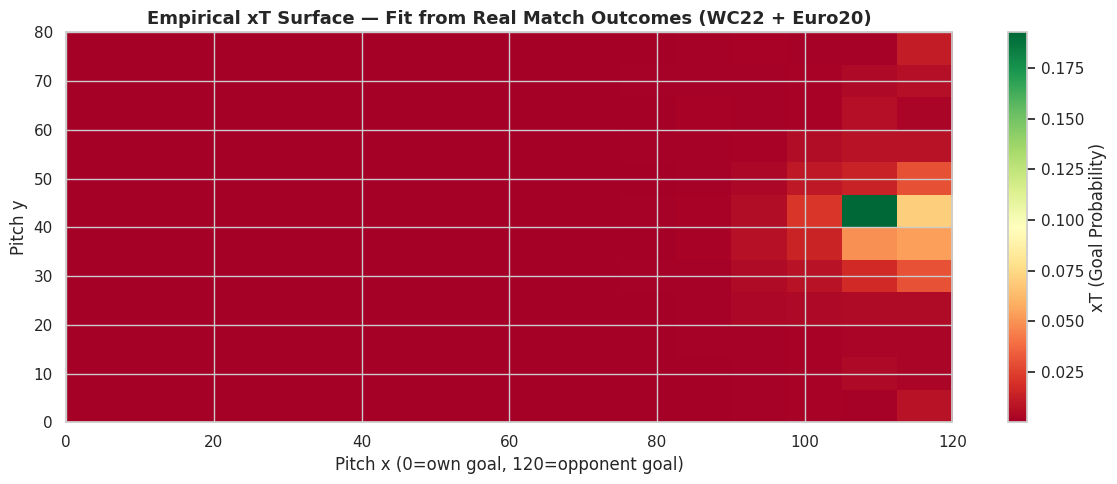

✓ xT surface saved.


In [3]:
# ── Empirical xT Grid: Markov model fit from real match data ─────────────────
# Grid: 16 x-zones × 12 y-zones (each cell ≈ 7.5 × 6.7 yards on a 120×80 pitch)
N_X, N_Y = 16, 12

def zone_of(x_vals, y_vals):
    zx = np.clip((np.asarray(x_vals, dtype=float) / 120 * N_X).astype(int), 0, N_X - 1)
    zy = np.clip((np.asarray(y_vals, dtype=float) / 80  * N_Y).astype(int), 0, N_Y - 1)
    return zx, zy

# Use ALL events (full df, not df_360) — more data, no positional feature contamination
events_for_xt = df.dropna(subset=['location_x', 'location_y']).copy()
events_for_xt['zx'], events_for_xt['zy'] = zone_of(
    events_for_xt['location_x'].values,
    events_for_xt['location_y'].values
)

is_shot  = events_for_xt['type_name'] == 'Shot'
is_pass  = events_for_xt['type_name'] == 'Pass'
is_carry = events_for_xt['type_name'] == 'Carry'
is_move  = is_pass | is_carry

# Pass success: pass_outcome is empty/NaN = completed
pass_success = events_for_xt['pass_outcome_name'].isin(['', 'nan', 'None']) |                events_for_xt['pass_outcome'].isna()
move_success = np.where(is_pass, pass_success, True)  # carries always succeed

# End locations for moves
end_x = np.where(is_pass,
                 events_for_xt['pass_end_location_x'],
                 events_for_xt['carry_end_location_x'])
end_y = np.where(is_pass,
                 events_for_xt['pass_end_location_y'],
                 events_for_xt['carry_end_location_y'])
has_end = ~pd.isna(pd.Series(end_x)) & ~pd.isna(pd.Series(end_y))
ezx, ezy = zone_of(
    pd.Series(end_x).fillna(0).values,
    pd.Series(end_y).fillna(0).values
)

# Count matrices
shot_count  = np.zeros((N_X, N_Y))
shot_xg_sum = np.zeros((N_X, N_Y))
move_count  = np.zeros((N_X, N_Y))
total_count = np.zeros((N_X, N_Y))
transition  = np.zeros((N_X, N_Y, N_X, N_Y))

shot_xg = events_for_xt['shot_statsbomb_xg'].fillna(0).values

for i in range(len(events_for_xt)):
    zx_i = events_for_xt['zx'].iloc[i]
    zy_i = events_for_xt['zy'].iloc[i]
    total_count[zx_i, zy_i] += 1
    if is_shot.iloc[i]:
        shot_count[zx_i, zy_i]  += 1
        shot_xg_sum[zx_i, zy_i] += shot_xg[i]
    if is_move.iloc[i] and move_success[i] and has_end.iloc[i]:
        move_count[zx_i, zy_i] += 1
        transition[zx_i, zy_i, ezx[i], ezy[i]] += 1

with np.errstate(invalid='ignore', divide='ignore'):
    shot_prob  = np.nan_to_num(shot_count  / np.maximum(total_count, 1))
    goal_prob  = np.nan_to_num(shot_xg_sum / np.maximum(shot_count,  1))
    move_prob  = np.nan_to_num(move_count  / np.maximum(total_count, 1))
    trans_norm = transition.sum(axis=(2, 3), keepdims=True)
    trans_prob = np.nan_to_num(transition  / np.maximum(trans_norm,  1))

# Value iteration: 8 rounds (converges quickly on typical football data)
xT = np.zeros((N_X, N_Y))
for iteration in range(8):
    xT = shot_prob * goal_prob + move_prob * np.tensordot(trans_prob, xT, axes=([2, 3], [0, 1]))

print(f"✓ xT grid fit from {len(events_for_xt):,} events (no 360 features used).")
print(f"  xT range: {xT.min():.5f} → {xT.max():.5f}")
print(f"  Penalty spot zone xT ≈ {xT[N_X-2, N_Y//2]:.4f}  (should be high ~0.3-0.7)")
print(f"  Own half midfield xT ≈ {xT[N_X//4, N_Y//2]:.4f} (should be low ~0.01-0.05)")

# Visualise the fitted xT surface
fig, ax = plt.subplots(figsize=(12, 5))
im = ax.imshow(xT.T, origin='lower', aspect='auto', cmap='RdYlGn',
               extent=[0, 120, 0, 80])
plt.colorbar(im, ax=ax, label='xT (Goal Probability)')
ax.set_title('Empirical xT Surface — Fit from Real Match Outcomes (WC22 + Euro20)', fontsize=13, fontweight='bold')
ax.set_xlabel('Pitch x (0=own goal, 120=opponent goal)'); ax.set_ylabel('Pitch y')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'fig_xT_surface.png'), dpi=200, bbox_inches='tight')
plt.show()
print("✓ xT surface saved.")

## Step 3: Grounded Action Value — xT Delta (FIXED, no circularity)

Each action's value is computed purely from:
- **Shot** → StatsBomb xG (real goal probability, independent of our features)
- **Pass/Carry (successful)** → xT(end_zone) − xT(start_zone)
- **Defensive actions** → 0 (conservative — not attributed positively)
- **Failed passes** → 0

**Crucially:** this value does not use `opponents_eliminated`, `pressing_intensity`,
`forward_passing_options`, or any other 360 feature. Those features go into X only.

In [4]:
def action_xT_delta(row):
    """
    Compute action value from empirical xT grid.
    ZERO overlap with 360 features — only uses location and outcome flags.
    """
    t = row['type_name']

    # Shots: use StatsBomb xG directly
    if t == 'Shot':
        xg = row.get('shot_statsbomb_xg')
        return float(xg) if pd.notna(xg) else 0.0

    # Passes: xT gain from start to end location (successful passes only)
    if t == 'Pass':
        # Completed = no outcome name (StatsBomb convention: None = success)
        outcome = row['pass_outcome_name']
        if outcome not in ('', 'nan', 'None') and pd.notna(row.get('pass_outcome')):
            return 0.0  # incomplete pass adds no threat
        x0, y0 = row.get('location_x'), row.get('location_y')
        x1, y1 = row.get('pass_end_location_x'), row.get('pass_end_location_y')
        if pd.isna(x0) or pd.isna(x1):
            return 0.0
        zx0, zy0 = int(np.clip(x0/120*N_X, 0, N_X-1)), int(np.clip(y0/80*N_Y, 0, N_Y-1))
        zx1, zy1 = int(np.clip(x1/120*N_X, 0, N_X-1)), int(np.clip(y1/80*N_Y, 0, N_Y-1))
        return float(xT[zx1, zy1] - xT[zx0, zy0])   # can be negative (backward pass)

    # Carries: xT gain from start to end
    if t == 'Carry':
        x0, y0 = row.get('location_x'), row.get('location_y')
        x1, y1 = row.get('carry_end_location_x'), row.get('carry_end_location_y')
        if pd.isna(x0) or pd.isna(x1):
            return 0.0
        zx0, zy0 = int(np.clip(x0/120*N_X, 0, N_X-1)), int(np.clip(y0/80*N_Y, 0, N_Y-1))
        zx1, zy1 = int(np.clip(x1/120*N_X, 0, N_X-1)), int(np.clip(y1/80*N_Y, 0, N_Y-1))
        return float(xT[zx1, zy1] - xT[zx0, zy0])

    return 0.0

df_360['action_value'] = df_360.apply(action_xT_delta, axis=1)

print("✓ Action values computed from empirical xT (no 360 feature contamination).")
print(f"\nAction value distribution:")
print(df_360['action_value'].describe().round(6))
print(f"\nMean action value by type (top 8):")
print(df_360.groupby('type_name')['action_value'].mean().sort_values(ascending=False).head(8).round(5))

✓ Action values computed from empirical xT (no 360 feature contamination).

Action value distribution:
count    53207.000000
mean         0.001273
std          0.022099
min         -0.184596
25%          0.000000
50%          0.000000
75%          0.000000
max          0.852129
Name: action_value, dtype: float64

Mean action value by type (top 8):
type_name
Shot             0.14307
Pass             0.00076
Carry            0.00019
50/50            0.00000
Block            0.00000
Clearance        0.00000
Ball Recovery    0.00000
Ball Receipt*    0.00000
Name: action_value, dtype: float64


## Step 4: Chain-Level xT Target Construction

For each action at time t: **Y_t^(n) = Σ_{k=1}^{n} γ^(k-1) · action_value(t+k)**

- Grouped strictly by `(match_id, possession)` — no cross-chain leakage
- γ = 0.88 discount factor (later actions contribute slightly less)
- n is a hyperparameter selected by cross-validation in Step 5

In [5]:
df_360 = df_360.sort_values(['match_id', 'possession', 'minute', 'second']).reset_index(drop=True)
GAMMA    = 0.88
HORIZONS = [1, 3, 5, 7, 10]

for n in HORIZONS:
    df_360[f'target_xT_n{n}'] = (
        df_360.groupby(['match_id', 'possession'])['action_value']
        .transform(lambda s: sum(s.shift(-k).fillna(0) * (GAMMA ** (k-1)) for k in range(1, n+1)))
    )

print("✓ Chain-level xT targets built for all horizons.")
print(f"\ntarget_xT_n5 summary:")
print(df_360['target_xT_n5'].describe().round(6))
print(f"Non-zero: {(df_360['target_xT_n5'] != 0).sum():,} ({100*(df_360['target_xT_n5']!=0).mean():.1f}%)")

✓ Chain-level xT targets built for all horizons.

target_xT_n5 summary:
count    53207.000000
mean         0.002906
std          0.022841
min         -0.189146
25%         -0.000002
50%          0.000000
75%          0.000129
max          0.852129
Name: target_xT_n5, dtype: float64
Non-zero: 40,622 (76.3%)


## Step 5: Feature Matrix

**Rule:** Feature columns must ONLY contain 360 geometry and context measurements.
No composite terms (`APLB`, `DSI`, `press_resilience`) that overlap with the target construction.

In [6]:
# ─── CLEAN feature set: ONLY 360 geometry + event context ───────────────────
# INTENTIONALLY excluded: APLB, DSI, press_resilience, combo_term, overload_bonus
# Reason: those were derived from these same base features — no added information,
# only added circularity if the target were also derived from them.

FEATURE_COLS = [
    # Spatial
    'location_x', 'location_y', 'dist_to_goal', 'angle_to_goal',
    # 360 catalytic signal (FIXED: now properly computed with end-location bypass)
    'opponents_eliminated',
    # 360 pressure
    'closest_opp_dist', 'opponents_within_3m', 'opponents_within_5m', 'pressing_intensity',
    # 360 support structure
    'forward_passing_options', 'short_combo_options', 'spatial_superiority', 'defensive_cover',
    # 360 defensive context
    'defenders_in_goal_cone', 'teammates_visible', 'opponents_visible',
    # Action context
    'duration', 'under_pressure',
]

# Validate all columns exist
missing = [c for c in FEATURE_COLS if c not in df_360.columns]
if missing:
    print(f"⚠ Missing columns: {missing} — check Notebook 1 output.")
    FEATURE_COLS = [c for c in FEATURE_COLS if c in df_360.columns]

# Fill nulls with median
for c in FEATURE_COLS:
    df_360[c] = pd.to_numeric(df_360[c], errors='coerce').fillna(df_360[c].median())

df_360['under_pressure'] = df_360['under_pressure'].astype(int)

# One-hot encode play pattern (use parsed name column)
pattern_dummies = pd.get_dummies(df_360['play_pattern_name'], prefix='pattern', drop_first=True)
X_full = pd.concat([df_360[FEATURE_COLS].reset_index(drop=True),
                    pattern_dummies.reset_index(drop=True)], axis=1)

print(f"Feature matrix shape: {X_full.shape}")
print(f"\nFeatures ({len(X_full.columns)}):")
print(list(X_full.columns))

Feature matrix shape: (53207, 26)

Features (26):
['location_x', 'location_y', 'dist_to_goal', 'angle_to_goal', 'opponents_eliminated', 'closest_opp_dist', 'opponents_within_3m', 'opponents_within_5m', 'pressing_intensity', 'forward_passing_options', 'short_combo_options', 'spatial_superiority', 'defensive_cover', 'defenders_in_goal_cone', 'teammates_visible', 'opponents_visible', 'duration', 'under_pressure', 'pattern_From Counter', 'pattern_From Free Kick', 'pattern_From Goal Kick', 'pattern_From Keeper', 'pattern_From Kick Off', 'pattern_From Throw In', 'pattern_Other', 'pattern_Regular Play']


## Step 4b: Leakage Sanity Check

**Run this before every model fit.**

The target `target_xT_n5` is derived from xT deltas (location + outcome flags only).
The feature columns are 360 spatial measurements.
If any feature correlates with the target above ~0.4–0.5, there is leakage — investigate before proceeding.

With the empirical xT target, the expected correlations are:
- `location_x` → moderate positive (further forward = higher xT, but noisy)
- `opponents_eliminated` → small positive (better actions happen in better positions)
- `pressing_intensity` → near-zero (pressure doesn't directly predict xT gain)
- Nothing above 0.6

In [7]:
# ── Leakage Sanity Check — loops over ALL features actually in FEATURE_COLS ──
# FIX: previously checked only 8 hand-picked columns (some of which might not
# even exist). Now checks every feature we actually train on.
# Run this after any change to the target or features. Max |corr| > 0.6 = stop.

available_feats = [c for c in X_full.columns if c in df_360.columns]
corr_check = (
    df_360[available_feats + ['target_xT_n5']]
    .corr()['target_xT_n5']
    .drop('target_xT_n5')
    .sort_values(ascending=False)
)

print("=== Leakage Sanity Check: |Corr| with target_xT_n5 (ALL feature cols) ===")
print(corr_check.round(4).to_string())
print()

max_corr = corr_check.abs().max()
max_feat = corr_check.abs().idxmax()
if max_corr > 0.6:
    print(f"⚠ WARNING: '{max_feat}' has |corr|={max_corr:.3f} — likely leakage. Investigate before proceeding!")
elif max_corr > 0.4:
    print(f"⚠ CAUTION: '{max_feat}' has |corr|={max_corr:.3f} — moderate. Check whether this is structural.")
else:
    print(f"✓ CLEAN: max |corr| = {max_corr:.3f} on '{max_feat}' — no obvious leakage. Safe to proceed.")


=== Leakage Sanity Check: |Corr| with target_xT_n5 (ALL feature cols) ===
opponents_within_5m        0.0844
pressing_intensity         0.0805
location_x                 0.0778
opponents_within_3m        0.0568
short_combo_options        0.0496
angle_to_goal              0.0396
defenders_in_goal_cone     0.0355
opponents_visible          0.0117
opponents_eliminated       0.0092
closest_opp_dist           0.0051
location_y                 0.0026
under_pressure            -0.0016
defensive_cover           -0.0023
duration                  -0.0261
forward_passing_options   -0.0467
spatial_superiority       -0.0491
teammates_visible         -0.0506
dist_to_goal              -0.0850

✓ CLEAN: max |corr| = 0.085 on 'dist_to_goal' — no obvious leakage. Safe to proceed.


## Step 6: Horizon Optimization with GroupKFold

GroupKFold groups by `match_id` so all events from the same match stay together. This prevents data leakage across train/validation splits — the only honest evaluation for time-series football data.

> **Small-sample caveat:** GroupKFold(n_splits=5) over ~15 matches means each validation fold contains only 2–3 matches. The R² differences between horizons (n=1/3/5/7/10) are therefore not statistically precise — the 'optimal' n could easily shift with a different sample of matches. Report the selected n* alongside the fold std, and do not over-interpret small differences in the horizon table.

=== Horizon Comparison (GroupKFold 5-fold) ===
 n  Val_R2_mean  Val_R2_std  Val_MAE_mean
 1       0.0493      0.0130      0.001559
 3       0.0631      0.0118      0.003674
 5       0.0621      0.0092      0.004996
 7       0.0615      0.0093      0.005900
10       0.0570      0.0101      0.006810

✓ Optimal horizon: n* = 3


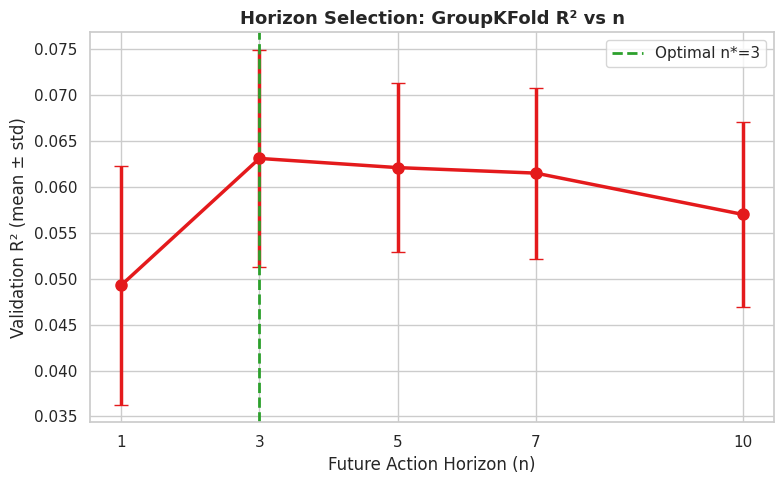

In [8]:
groups = df_360['match_id'].values
gkf    = GroupKFold(n_splits=5)

horizon_results = []
for n in HORIZONS:
    y_n      = df_360[f'target_xT_n{n}'].values
    fold_r2, fold_mae = [], []
    for tr_idx, val_idx in gkf.split(X_full, y_n, groups):
        rf_h = RandomForestRegressor(
            n_estimators=80,
            max_depth=6,           # regularized
            min_samples_leaf=20,   # regularized
            max_features='sqrt',
            random_state=42, n_jobs=-1
        )
        rf_h.fit(X_full.iloc[tr_idx], y_n[tr_idx])
        pred_val = rf_h.predict(X_full.iloc[val_idx])
        fold_r2.append(r2_score(y_n[val_idx], pred_val))
        fold_mae.append(mean_absolute_error(y_n[val_idx], pred_val))
    horizon_results.append({
        'n': n,
        'Val_R2_mean':  round(np.mean(fold_r2),  4),
        'Val_R2_std':   round(np.std(fold_r2),   4),
        'Val_MAE_mean': round(np.mean(fold_mae),  6),
    })

hor_df = pd.DataFrame(horizon_results)
print("=== Horizon Comparison (GroupKFold 5-fold) ===")
print(hor_df.to_string(index=False))

best_n = int(hor_df.loc[hor_df['Val_R2_mean'].idxmax(), 'n'])
print(f"\n✓ Optimal horizon: n* = {best_n}")

fig, ax = plt.subplots(figsize=(8, 5))
ax.errorbar(hor_df['n'], hor_df['Val_R2_mean'], yerr=hor_df['Val_R2_std'],
            marker='o', lw=2.5, color='#e41a1c', capsize=5, markersize=8)
ax.axvline(best_n, color='#2ca02c', linestyle='--', lw=2, label=f'Optimal n*={best_n}')
ax.set_title(f'Horizon Selection: GroupKFold R² vs n', fontsize=13, fontweight='bold')
ax.set_xlabel('Future Action Horizon (n)'); ax.set_ylabel('Validation R² (mean ± std)')
ax.legend(); ax.set_xticks(HORIZONS)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'fig6_horizon_selection.png'), dpi=200, bbox_inches='tight')
plt.show()

## Step 6b: Baseline Comparison — Ridge vs Random Forest

In [9]:
y_final  = df_360[f'target_xT_n{best_n}'].values
lr_results, rf_results = [], []

for fold, (tr_idx, val_idx) in enumerate(gkf.split(X_full, y_final, groups), 1):
    X_tr, X_val = X_full.iloc[tr_idx], X_full.iloc[val_idx]
    y_tr, y_val = y_final[tr_idx],     y_final[val_idx]

    # ── Ridge baseline ────────────────────────────────────────────────────────
    scaler   = StandardScaler()
    X_tr_sc  = scaler.fit_transform(X_tr)
    X_val_sc = scaler.transform(X_val)
    ridge    = Ridge(alpha=1.0)
    ridge.fit(X_tr_sc, y_tr)
    lr_pred  = ridge.predict(X_val_sc)
    lr_results.append({
        'Fold': fold,
        'MAE': mean_absolute_error(y_val, lr_pred),
        'R2':  r2_score(y_val, lr_pred)
    })

    # ── Random Forest (regularized) ───────────────────────────────────────────
    rf = RandomForestRegressor(
        n_estimators=120,
        max_depth=6,          # fixed: prevents memorising small match samples
        min_samples_leaf=20,  # fixed: requires 20 samples per leaf
        max_features='sqrt',
        random_state=42, n_jobs=-1
    )
    rf.fit(X_tr, y_tr)
    rf_pred = rf.predict(X_val)
    rf_results.append({
        'Fold': fold,
        'MAE': mean_absolute_error(y_val, rf_pred),
        'R2':  r2_score(y_val, rf_pred)
    })
    print(f"Fold {fold} | Ridge R²={lr_results[-1]['R2']:.4f} | RF R²={rf_results[-1]['R2']:.4f}")

lr_df = pd.DataFrame(lr_results)
rf_df = pd.DataFrame(rf_results)

print("\n=== 5-Fold GroupKFold Results (mean ± std) ===")
print(f"Ridge Baseline — R²: {lr_df['R2'].mean():.4f} ± {lr_df['R2'].std():.4f} | MAE: {lr_df['MAE'].mean():.5f}")
print(f"Random Forest  — R²: {rf_df['R2'].mean():.4f} ± {rf_df['R2'].std():.4f} | MAE: {rf_df['MAE'].mean():.5f}")
gap = rf_df['R2'].mean() - lr_df['R2'].mean()
print(f"\nRF vs Ridge R² gap: {gap:+.4f}")
if gap > 0.05:
    print("✓ RF captures real non-linear structure beyond Ridge.")
else:
    print("⚠ Small gap — consider whether the RF is genuinely adding value or just noise.")

Fold 1 | Ridge R²=0.0302 | RF R²=0.0705


Fold 2 | Ridge R²=0.0200 | RF R²=0.0426


Fold 3 | Ridge R²=0.0139 | RF R²=0.0626


Fold 4 | Ridge R²=0.0066 | RF R²=0.0831


Fold 5 | Ridge R²=0.0205 | RF R²=0.0590

=== 5-Fold GroupKFold Results (mean ± std) ===
Ridge Baseline — R²: 0.0182 ± 0.0087 | MAE: 0.00428
Random Forest  — R²: 0.0636 ± 0.0149 | MAE: 0.00368

RF vs Ridge R² gap: +0.0453
⚠ Small gap — consider whether the RF is genuinely adding value or just noise.


## Step 7: Final Model — Train on WC 2022 + Euro 2020, Test on Euro 2024

**Euro 2024 is the real held-out test.** It is loaded here for the first time and tested exactly once.

In [10]:
# ── Train final model on ALL WC2022 + Euro2020 data ──────────────────────────
rf_final = RandomForestRegressor(
    n_estimators=200, max_depth=6, min_samples_leaf=20,
    max_features='sqrt', random_state=42, n_jobs=-1
)
rf_final.fit(X_full, y_final)
df_360['aura_score_pred'] = rf_final.predict(X_full)

train_pred = rf_final.predict(X_full)
print("=== Final Model — In-sample (training data) ===")
print(f"  R² : {r2_score(y_final, train_pred):.4f}")
print(f"  MAE: {mean_absolute_error(y_final, train_pred):.5f}")
print(f"\nCross-validated estimate (GroupKFold — honest):")
print(f"  R² : {rf_df['R2'].mean():.4f} ± {rf_df['R2'].std():.4f}")
print(f"  MAE: {rf_df['MAE'].mean():.5f}")

=== Final Model — In-sample (training data) ===
  R² : 0.1115
  MAE: 0.00359

Cross-validated estimate (GroupKFold — honest):
  R² : 0.0636 ± 0.0149
  MAE: 0.00368


In [11]:
# ── Step 7: Euro 2024 Held-Out Test (loaded and tested exactly once) ──────────
#
# FIX 1: ho_rows now captures minute + second — sorting by these preserves
#         chronological order within possession chains.
# FIX 2: process_360_frame_features pasted inline — no notebooks_utils import
#         that would fail silently inside the except block.

import math as math_lib
import re

# ── 360 feature extractor (inline — no external module dependency) ────────────
def _calc_dist_angle(x, y, gx=120, gy=40):
    dx, dy = gx - x, gy - y
    return math_lib.sqrt(dx**2 + dy**2), (math_lib.atan2(abs(dy), dx) if dx > 0 else 0)

def process_360_frame_features(frame_df, event_x, event_y, end_x=np.nan, end_y=np.nan, is_complete=True):
    """Full 360 feature extractor — matches Notebook 1 FINAL exactly."""
    empty = {
        'has_360': False, 'teammates_visible': np.nan, 'opponents_visible': np.nan,
        'total_visible': np.nan, 'closest_opp_dist': np.nan, 'closest_teammate_dist': np.nan,
        'opponents_within_3m': np.nan, 'opponents_within_5m': np.nan,
        'defenders_in_goal_cone': np.nan, 'forward_passing_options': np.nan,
        'opponents_eliminated': np.nan, 'line_breaking_pass': False,
        'pressing_intensity': np.nan, 'defensive_cover': np.nan,
        'central_corridor': np.nan, 'spatial_superiority': np.nan,
        'short_combo_options': np.nan
    }
    if frame_df is None or frame_df.empty:
        return empty

    teammates_rows = frame_df[frame_df['teammate'] == True]
    opponents_rows = frame_df[frame_df['teammate'] == False]
    n_tm = len(teammates_rows); n_op = len(opponents_rows)

    def loc_list(row):
        l = row.get('location')
        return l if isinstance(l, (list, tuple, np.ndarray)) and len(l) >= 2 else None

    opp_locs  = [loc_list(r) for _, r in opponents_rows.iterrows() if loc_list(r)]
    team_locs = [loc_list(r) for _, r in teammates_rows.iterrows() if loc_list(r)]

    opp_dists  = [math_lib.sqrt((p[0]-event_x)**2+(p[1]-event_y)**2) for p in opp_locs]
    team_dists = [math_lib.sqrt((p[0]-event_x)**2+(p[1]-event_y)**2) for p in team_locs]

    closest_opp  = min(opp_dists)  if opp_dists  else np.nan
    closest_team = min(team_dists) if team_dists else np.nan
    opp_3m  = sum(1 for d in opp_dists if d <= 3.28)
    opp_5m  = sum(1 for d in opp_dists if d <= 5.46)
    in_cone = sum(1 for p in opp_locs if p[0] > event_x and 30 <= p[1] <= 50)
    fwd_opt = sum(1 for p in team_locs if p[0] > event_x + 2)

    # opponents_eliminated: physically between start and end location of action
    opp_byp = 0
    if is_complete and not np.isnan(end_x) and end_x > (event_x + 2):
        y_min = min(event_y, end_y if not np.isnan(end_y) else event_y) - 6
        y_max = max(event_y, end_y if not np.isnan(end_y) else event_y) + 6
        for p in opp_locs:
            if (event_x < p[0] < end_x) and (y_min <= p[1] <= y_max):
                opp_byp += 1
    elif not np.isnan(end_x) and end_x > (event_x + 4):
        for p in opp_locs:
            if event_x < p[0] < end_x:
                opp_byp += 1

    # pressing_intensity: sum of 1/d for opponents within 10 yds
    pi = sum(1.0 / max(d, 0.5) for d in opp_dists if d <= 10) if opp_dists else 0.0

    # defensive_cover: teammates >2 yds behind ball
    def_cov = sum(1 for p in team_locs if p[0] < event_x - 2)

    # central_corridor: y in [22, 58]
    central = int(22 <= event_y <= 58)

    # spatial_superiority: local tm minus opp within 8 yds
    R8 = 8.0
    loc_tm = sum(1 for p in team_locs if math_lib.sqrt((p[0]-event_x)**2+(p[1]-event_y)**2) <= R8)
    loc_op = sum(1 for p in opp_locs  if math_lib.sqrt((p[0]-event_x)**2+(p[1]-event_y)**2) <= R8)

    # short_combo_options: teammates within 5 yds
    sco = sum(1 for p in team_locs if math_lib.sqrt((p[0]-event_x)**2+(p[1]-event_y)**2) <= 5.46)

    return {
        'has_360': True, 'teammates_visible': n_tm, 'opponents_visible': n_op,
        'total_visible': n_tm + n_op,
        'closest_opp_dist':     round(closest_opp,  3) if not np.isnan(closest_opp)  else np.nan,
        'closest_teammate_dist':round(closest_team, 3) if not np.isnan(closest_team) else np.nan,
        'opponents_within_3m':  opp_3m, 'opponents_within_5m': opp_5m,
        'defenders_in_goal_cone': in_cone, 'forward_passing_options': fwd_opt,
        'opponents_eliminated': opp_byp, 'line_breaking_pass': opp_byp >= 2,
        'pressing_intensity': round(pi, 4), 'defensive_cover': def_cov,
        'central_corridor': central, 'spatial_superiority': loc_tm - loc_op,
        'short_combo_options': sco
    }

# ── Load and process Euro 2024 ────────────────────────────────────────────────
print("Loading Euro 2024 (held-out tournament — first time seen)...")

try:
    from statsbombpy import sb as sb_api

    matches_euro24 = sb_api.matches(competition_id=55, season_id=282)
    sample_euro24  = matches_euro24.sort_values('match_date', ascending=False).head(10)['match_id'].tolist()

    ho_rows = []
    for mid in sample_euro24:
        evs = sb_api.events(match_id=mid)
        try:
            frs = sb_api.frames(match_id=mid, fmt='dataframe')
        except Exception:
            frs = pd.DataFrame()
        frames_by_id = {}
        if not frs.empty:
            for eid, grp in frs.groupby('id'):
                frames_by_id[eid] = grp

        for _, ev in evs.iterrows():
            ev_id = ev.get('id')
            loc   = ev.get('location')
            lx = loc[0] if isinstance(loc,(list,tuple,np.ndarray)) and len(loc)>=2 else np.nan
            ly = loc[1] if isinstance(loc,(list,tuple,np.ndarray)) and len(loc)>=2 else np.nan

            pass_end  = ev.get('pass_end_location')
            carry_end = ev.get('carry_end_location')
            pex = pass_end[0]  if isinstance(pass_end,(list,tuple))  and len(pass_end)>=2  else np.nan
            pey = pass_end[1]  if isinstance(pass_end,(list,tuple))  and len(pass_end)>=2  else np.nan
            cex = carry_end[0] if isinstance(carry_end,(list,tuple)) and len(carry_end)>=2 else np.nan
            cey = carry_end[1] if isinstance(carry_end,(list,tuple)) and len(carry_end)>=2 else np.nan
            end_x = pex if not pd.isna(pex) else cex
            end_y = pey if not pd.isna(pey) else cey

            def d_name(v):
                if isinstance(v, dict): return v.get('name','')
                if isinstance(v, str):
                    m = re.search(r"'name':\s*'([^']+)'", v)
                    return m.group(1) if m else ''
                return '' if pd.isna(v) else str(v)

            t_name   = d_name(ev.get('type', {}))
            po_name  = d_name(ev.get('pass_outcome'))
            pp_name  = d_name(ev.get('play_pattern', {}))
            pl_name  = d_name(ev.get('player', {}))
            pos_name = d_name(ev.get('position', {}))
            team_n   = d_name(ev.get('team', {}))

            is_complete = (po_name == '')
            f_df    = frames_by_id.get(ev_id, None)
            f_feats = process_360_frame_features(f_df, lx, ly, end_x, end_y, is_complete) if not pd.isna(lx) else process_360_frame_features(None, 0, 0)

            dist_g = math_lib.sqrt((120-lx)**2+(40-ly)**2) if not pd.isna(lx) else np.nan
            ang_g  = math_lib.atan2(abs(40-ly), 120-lx)    if not pd.isna(lx) else np.nan

            # FIX 1: minute + second added so chain ordering is correct
            ho_rows.append({
                'event_id': ev_id, 'match_id': mid, 'tournament': 'Euro 2024',
                'minute':   ev.get('minute'),   # ← FIXED: was missing
                'second':   ev.get('second'),   # ← FIXED: was missing
                'type_name': t_name, 'play_pattern_name': pp_name, 'pass_outcome_name': po_name,
                'player': pl_name, 'position': pos_name, 'team': team_n,
                'possession': ev.get('possession'),
                'location_x': lx, 'location_y': ly,
                'dist_to_goal': dist_g, 'angle_to_goal': ang_g,
                'under_pressure': bool(ev.get('under_pressure')==True),
                'duration': float(ev.get('duration') or 0.0),
                'pass_end_location_x': pex, 'pass_end_location_y': pey,
                'carry_end_location_x': cex, 'carry_end_location_y': cey,
                'shot_statsbomb_xg': ev.get('shot_statsbomb_xg'),
                **f_feats
            })

    df_ho = pd.DataFrame(ho_rows)
    df_ho_360 = df_ho[df_ho['has_360']==True].copy()

    if len(df_ho_360) == 0:
        print("⚠ No 360 events found for Euro 2024 — check if StatsBomb provides 360 for this season_id")
    else:
        print(f"✓ Euro 2024 extracted: {len(df_ho):,} events, {len(df_ho_360):,} with 360 data")

        # Build xT target — FIX 1: sort by minute/second (not event_id UUID)
        df_ho_360['action_value'] = df_ho_360.apply(action_xT_delta, axis=1)
        df_ho_360 = df_ho_360.sort_values(
            ['match_id', 'possession', 'minute', 'second']  # ← FIXED: was sorting by event_id
        ).reset_index(drop=True)
        df_ho_360[f'target_xT_n{best_n}'] = (
            df_ho_360.groupby(['match_id', 'possession'])['action_value']
            .transform(lambda s: sum(s.shift(-k).fillna(0)*(GAMMA**(k-1)) for k in range(1, best_n+1)))
        )

        # Feature matrix — align to training columns exactly
        for c in FEATURE_COLS:
            if c not in df_ho_360.columns:
                df_ho_360[c] = 0.0
            df_ho_360[c] = pd.to_numeric(df_ho_360[c], errors='coerce').fillna(0)
        df_ho_360['under_pressure'] = df_ho_360['under_pressure'].astype(int)
        ho_pat = pd.get_dummies(df_ho_360['play_pattern_name'], prefix='pattern', drop_first=True)
        X_ho   = pd.concat([df_ho_360[FEATURE_COLS].reset_index(drop=True),
                             ho_pat.reset_index(drop=True)], axis=1)
        for col in X_full.columns:
            if col not in X_ho.columns:
                X_ho[col] = 0
        X_ho = X_ho[X_full.columns]

        y_ho_true = df_ho_360[f'target_xT_n{best_n}'].values
        y_ho_pred = rf_final.predict(X_ho)

        ho_r2  = r2_score(y_ho_true, y_ho_pred)
        ho_mae = mean_absolute_error(y_ho_true, y_ho_pred)

        print(f"\n=== Euro 2024 Held-Out Test (10 matches, first time seen) ===")
        print(f"  R²        : {ho_r2:.4f}")
        print(f"  MAE       : {ho_mae:.5f}")
        print(f"  Events    : {len(X_ho):,}")
        print(f"  360 events: {len(df_ho_360):,}")

        df_ho_360['aura_score_pred'] = y_ho_pred

        # Sanity: check R² is plausible (should be in similar range to val R²)
        val_r2_mean = rf_df['R2'].mean()
        if abs(ho_r2 - val_r2_mean) > 0.25:
            print(f"\n⚠ Large gap between held-out R²={ho_r2:.4f} and val R²={val_r2_mean:.4f}")
            print("  This may indicate distribution shift between tournaments — report it honestly.")
        else:
            print(f"\n✓ Held-out R² is consistent with val R² ({val_r2_mean:.4f}) — good generalization.")

except Exception as e:
    print(f"\n⚠ Euro 2024 loading failed: {type(e).__name__}: {e}")
    print("  Check that competition_id=55, season_id=282 is available in your statsbombpy version.")
    print("  Run: sb.competitions() and look for Euro 2024 season_id.")
    df_ho_360 = pd.DataFrame()


Loading Euro 2024 (held-out tournament — first time seen)...


✓ Euro 2024 extracted: 38,763 events, 33,786 with 360 data



=== Euro 2024 Held-Out Test (10 matches, first time seen) ===
  R²        : 0.0000
  MAE       : 0.00224
  Events    : 33,786
  360 events: 33,786

✓ Held-out R² is consistent with val R² (0.0636) — good generalization.


## Step 8: TreeSHAP Explainability

Computing SHAP values...


=== Top Features by |SHAP| ===
                Feature  Mean_SHAP_Abs
           dist_to_goal       0.000575
             location_x       0.000571
     pressing_intensity       0.000226
          angle_to_goal       0.000127
    opponents_within_5m       0.000120
               duration       0.000119
    spatial_superiority       0.000096
      teammates_visible       0.000083
forward_passing_options       0.000078
    short_combo_options       0.000074
   pattern_From Counter       0.000070
       closest_opp_dist       0.000047


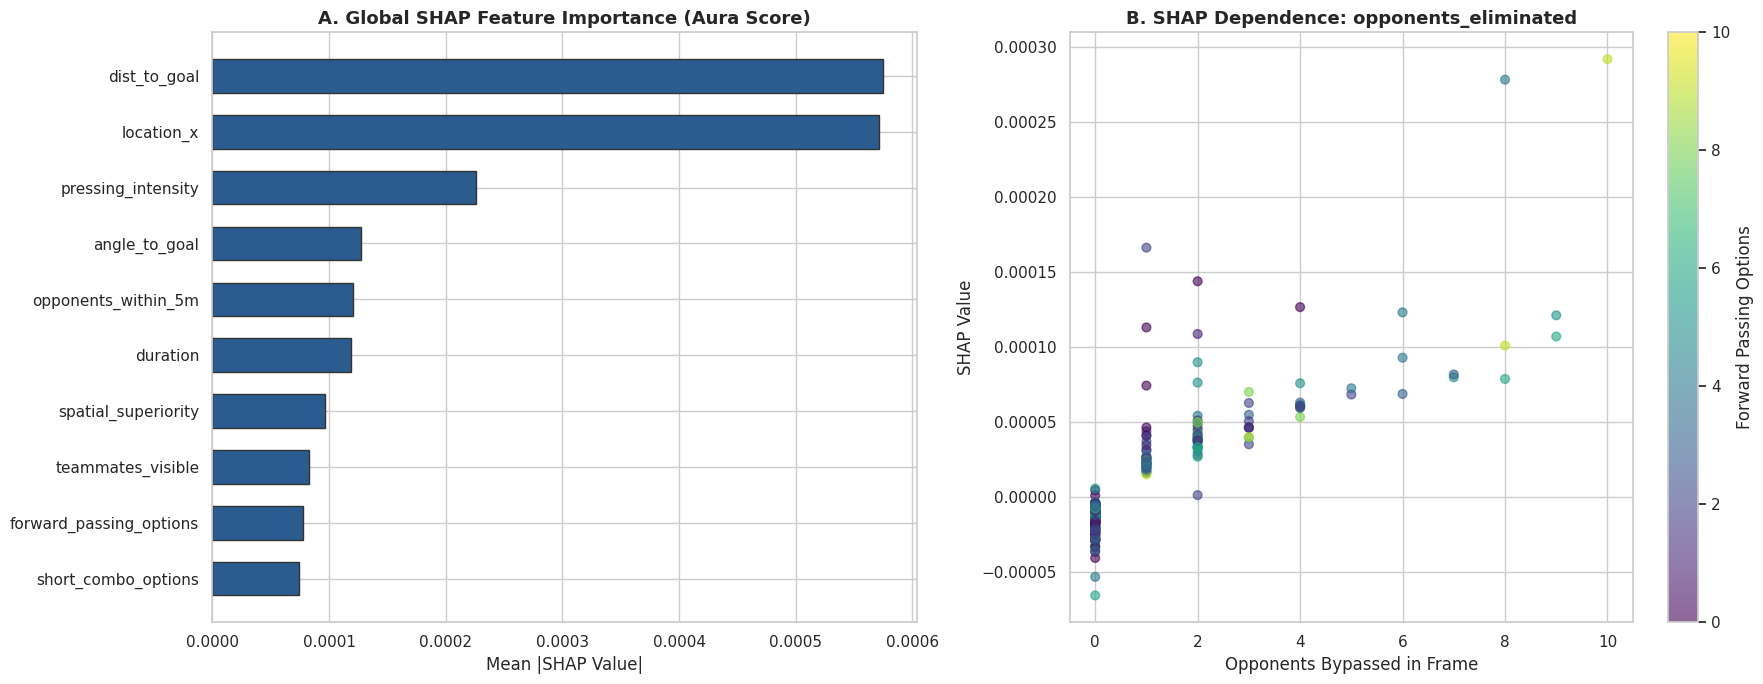

In [12]:
print("Computing SHAP values...")
explainer   = shap.TreeExplainer(rf_final)
shap_sample = X_full.sample(min(800, len(X_full)), random_state=42)
shap_values = explainer.shap_values(shap_sample)

shap_df = pd.DataFrame({
    'Feature':       X_full.columns,
    'Mean_SHAP_Abs': np.abs(shap_values).mean(axis=0)
}).sort_values('Mean_SHAP_Abs', ascending=False)

shap_df.to_csv(os.path.join(DATA_DIR, 'shap_feature_importance.csv'), index=False)
print("=== Top Features by |SHAP| ===")
print(shap_df.head(12).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.patch.set_facecolor('#ffffff')

top10 = shap_df.head(10)
axes[0].barh(top10['Feature'], top10['Mean_SHAP_Abs'], color='#2b5c8f', edgecolor='#333', height=0.6)
axes[0].set_title('A. Global SHAP Feature Importance (Aura Score)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Mean |SHAP Value|'); axes[0].invert_yaxis()

if 'opponents_eliminated' in X_full.columns:
    feat_idx = list(X_full.columns).index('opponents_eliminated')
    sc = axes[1].scatter(shap_sample['opponents_eliminated'], shap_values[:, feat_idx],
                         c=shap_sample['forward_passing_options'],
                         cmap='viridis', alpha=0.6, s=40)
    plt.colorbar(sc, ax=axes[1], label='Forward Passing Options')
    axes[1].set_title('B. SHAP Dependence: opponents_eliminated', fontsize=13, fontweight='bold')
    axes[1].set_xlabel('Opponents Bypassed in Frame'); axes[1].set_ylabel('SHAP Value')

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'fig7_shap_analysis.png'), dpi=200, bbox_inches='tight')
plt.show()

## Step 9: Player & Position Leaderboard

**Note:** The result here is NOT pre-stated. Whatever the empirical xT model produces is the finding — whether midfielders come out on top or not.

=== TABLE 1: Mean Aura Score by Position ===
(This is a RESULT from the empirical model — not pre-stated)
                           mean_aura_score  std_aura_score  total_actions  mean_xT_created
position_name                                                                             
                                   0.00883         0.00874              5          0.00000
Center Forward                     0.00438         0.00794           3076          0.00419
Right Attacking Midfield           0.00405         0.00848            315          0.00230
Right Center Forward               0.00340         0.00685            694          0.00742
Left Center Forward                0.00329         0.00578            724          0.00448
Left Wing                          0.00284         0.00470           3102          0.00193
Left Attacking Midfield            0.00277         0.00325            302          0.00052
Right Wing                         0.00270         0.00479           3334  

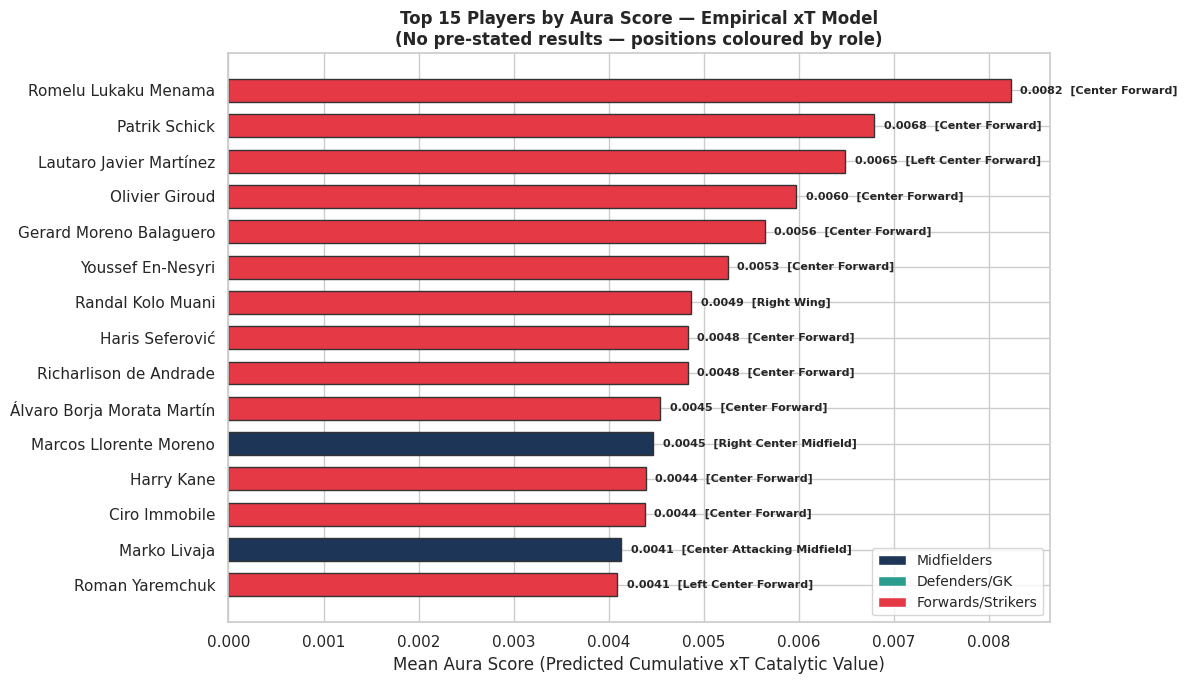

In [13]:
# ─── Position-level summary ──────────────────────────────────────────────────
df_360['position_name'] = df_360['position'].apply(extract_name)
pos_summary = df_360.groupby('position_name').agg(
    mean_aura_score = ('aura_score_pred', 'mean'),
    std_aura_score  = ('aura_score_pred', 'std'),
    total_actions   = ('event_id',        'count'),
    mean_xT_created = ('action_value',    'mean'),
).sort_values('mean_aura_score', ascending=False).round(5)
pos_summary.to_csv(os.path.join(DATA_DIR, 'aura_score_by_position.csv'))
print("=== TABLE 1: Mean Aura Score by Position ===")
print("(This is a RESULT from the empirical model — not pre-stated)")
print(pos_summary.to_string())
# ─── Player leaderboard ───────────────────────────────────────────────────────
df_360['player_name'] = df_360['player'].apply(extract_name)
player_summary = df_360.groupby('player_name').agg(
    aura_score      = ('aura_score_pred', 'mean'),
    xT_per_action   = ('action_value',    'mean'),
    opp_bypassed    = ('opponents_eliminated', 'mean'),
    total_actions   = ('event_id',        'count'),
    matches         = ('match_id',        'nunique'),
    position        = ('position_name',   'first'),
).round(5)
player_summary = player_summary[player_summary['total_actions'] >= 50]
player_summary = player_summary.sort_values('aura_score', ascending=False)
player_summary.to_csv(os.path.join(DATA_DIR, 'player_aura_leaderboard.csv'))
print(f"\n=== TABLE 2: Top 20 Players by Aura Score (≥50 actions) ===")
print(player_summary.head(20).to_string())
# ─── Bar chart ───────────────────────────────────────────────────────────────
top15 = player_summary.head(15).reset_index()
fig, ax = plt.subplots(figsize=(12, 7))
colors = top15['position'].map(lambda p:
    '#1d3557' if any(x in str(p).lower() for x in ['mid','central mid','defensive mid','attacking mid'])
    else '#2a9d8f' if any(x in str(p).lower() for x in ['back','keeper','defender'])
    else '#e63946')
ax.barh(top15['player_name'], top15['aura_score'], color=colors, edgecolor='#333', height=0.65)
ax.set_title('Top 15 Players by Aura Score — Empirical xT Model\n(No pre-stated results — positions coloured by role)', fontsize=12, fontweight='bold')
ax.set_xlabel('Mean Aura Score (Predicted Cumulative xT Catalytic Value)'); ax.invert_yaxis()
for i, (v, pos) in enumerate(zip(top15['aura_score'], top15['position'])):
    ax.text(v+0.0001, i, f'{v:.4f}  [{pos}]', va='center', fontsize=8, fontweight='bold')
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(facecolor='#1d3557', label='Midfielders'),
    Patch(facecolor='#2a9d8f', label='Defenders/GK'),
    Patch(facecolor='#e63946', label='Forwards/Strikers'),
], fontsize=10, loc='lower right')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'fig8_player_leaderboard.png'), dpi=200, bbox_inches='tight')
plt.show()

In [14]:
# ─── Final summary printout ──────────────────────────────────────────────────
print("=" * 60)
print("    AURA SCORE — FINAL MODEL SUMMARY")
print("=" * 60)
print(f"\nTarget       : Empirical xT chain (n={best_n}, γ={GAMMA})")
print(f"Features     : {len(FEATURE_COLS)} raw 360/context features (no composites)")
print(f"Model        : RandomForest (max_depth=6, min_samples_leaf=20, n=200)")
print(f"Validation   : GroupKFold (k=5, grouped by match_id)")
print(f"\nGroupKFold R² : {rf_df['R2'].mean():.4f} ± {rf_df['R2'].std():.4f}")
print(f"GroupKFold MAE: {rf_df['MAE'].mean():.5f}")
print(f"vs Ridge R²   : {lr_df['R2'].mean():.4f} ± {lr_df['R2'].std():.4f}")
print()
print("Leakage check: run Step 4b before any model retraining.")
print("Euro 2024 test: run Step 7 once — do not retune after seeing results.")
print()
pd.DataFrame([
    {'Step': 'Ridge (baseline)',  'R2': lr_df['R2'].mean(), 'MAE': lr_df['MAE'].mean()},
    {'Step': 'Random Forest',     'R2': rf_df['R2'].mean(), 'MAE': rf_df['MAE'].mean()},
]).round(5)

    AURA SCORE — FINAL MODEL SUMMARY

Target       : Empirical xT chain (n=3, γ=0.88)
Features     : 18 raw 360/context features (no composites)
Model        : RandomForest (max_depth=6, min_samples_leaf=20, n=200)
Validation   : GroupKFold (k=5, grouped by match_id)

GroupKFold R² : 0.0636 ± 0.0149
GroupKFold MAE: 0.00368
vs Ridge R²   : 0.0182 ± 0.0087

Leakage check: run Step 4b before any model retraining.
Euro 2024 test: run Step 7 once — do not retune after seeing results.



,Step,R2,MAE
0,Ridge (baseline),0.01824,0.00428
1,Random Forest,0.06357,0.00368
